In [1]:
import matplotlib
import matplotlib.colors
import matplotlib.cm
import matplotlib.pyplot as plt
import matplotlib as mpl

#from typhon import plots
import numpy as np
import xarray as xr
import konrad
from cycler import cycler
from string import ascii_lowercase, ascii_uppercase
from pathlib import Path
import pandas as pd

xr.set_options(keep_attrs=True)

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:40113")
client

<Client: 'tcp://127.0.0.1:40113' processes=8 threads=56, memory=1.11 TiB>

# Functions

In [2]:
def rad_cal(atmosphere, zenith_angle=85):
    plev = atmosphere.coords['plev']
    phlev = atmosphere.coords['phlev']
    #plev = pcap.plev.values
    #atmosphere = konrad.atmosphere.Atmosphere(plev)
    #print(pcap['O3_m'].squeeze().values[np.newaxis,:])
    #atmosphere['O3'][:] = pcap['O3_m'].squeeze().values[np.newaxis,1:]
    #atmosphere['H2O'][:] = pcap['H2O_m'].squeeze().values[np.newaxis,1:]#*10
    #atmosphere['T'][:] = pcap['te_m'].squeeze().values[np.newaxis,1:]

    surface = konrad.surface.SlabOcean.from_atmosphere(atmosphere)
    #surface['temperature'][:] = [300]
# Create cloud component (here clear-sky).
    cloud = konrad.cloud.ClearSky.from_atmosphere(atmosphere)
    
    # Create aerosol component (here clear-sky).
    #aerosol = konrad.aerosol.NoAerosol(atmosphere)
    
    # Setup the RRTMG radiation component (choose zenith angle and solar constant).
    rrtmg = konrad.radiation.RRTMG(zenith_angle=zenith_angle)#47.88)
    rrtmg.calc_radiation(atmosphere, surface, cloud)#, aerosol)  # Actual RT simulation
    #print(rrtmg['sw_flxu'].shape)
    ds_out_hr = xr.Dataset(
        data_vars=dict(
            lw_htngrt=(["plev"], rrtmg['lw_htngrt'].squeeze()),
            sw_htngrt=(["plev"], rrtmg['sw_htngrt'].squeeze()),
        ),
        coords=dict(plev = plev),
    )
    ds_out_fluxes = xr.Dataset(
        data_vars=dict(
            sw_flxu=(["phlev"], rrtmg['sw_flxu'].squeeze()),
            sw_flxd=(["phlev"], rrtmg['sw_flxd'].squeeze()),
            lw_flxu=(["phlev"], rrtmg['lw_flxu'].squeeze()),
            lw_flxd=(["phlev"], rrtmg['lw_flxd'].squeeze()),
        ),
        coords=dict(phlev = phlev),
    )
    return ds_out_hr, ds_out_fluxes#(rrtmg['lw_htngrt'].squeeze(), rrtmg['sw_htngrt'].squeeze)

def interpolate_mls(ds_mls, sel_time, atmosphere):
    ds_mls_interp = ds_mls.interp(pressure = atmosphere['plev'])
    temp = ds_mls_interp['O3'].sel(time = [sel_time.values]).fillna(0)/1e6
    diff_o3 = temp.values+atmosphere['O3']
    mask = diff_o3 < 0
    diff_o3[mask] = 0
    temp = ds_mls_interp['h2o'].sel(time = [sel_time.values]).fillna(0)/1e6
    diff_wv = temp.values+atmosphere['H2O']
    mask = diff_wv < 0
    diff_wv[mask] = 0
    return diff_o3, diff_wv

def perturb(ds_mls_sel, atmosphere, perturb_switch = 'both'):
    zenit_arr = np.arange(60,90,4)
    time_arr = ds_mls_sel.time[:]
    
    diff_time_ls = []
    for sel_time in time_arr:
        #print(sel_time)
        diff_o3, diff_wv = interpolate_mls(ds_mls_sel, sel_time, atmosphere)
        
        atmosphere2 = atmosphere.copy()
        if perturb_switch == 'both':
            atmosphere2['H2O'][0,:] = diff_wv
            atmosphere2['O3'][0,:] = diff_o3
        elif perturb_switch == 'H2O':
            atmosphere2['H2O'][0,:] = diff_wv
        elif perturb_switch == 'O3':
            atmosphere2['O3'][0,:] = diff_o3
    
        diff_ls = []
        for izenith in zenit_arr:
            ds_hr_wo, ds_fluxes_wo = rad_cal(atmosphere)
            ds_hr_w, ds_fluxes_w = rad_cal(atmosphere2)
            diff = ds_hr_w-ds_hr_wo
            diff.expand_dims('zenith')
            diff['zenith'] = [izenith]
            diff_ls.append(diff)
        
        diff_time_ls.append(xr.concat(diff_ls, dim = 'zenith'))

    return diff_time_ls

def process_diff(diff_time_ls,switch):
    diff_all = xr.concat(diff_time_ls, dim = 'time')
    #diff_all['time'] = time_arr
    diff_all['plev'] = diff_all.plev.values/100.
    diff_all['plev'].attrs['units'] = 'hPa'
    diff_all['plev'].attrs['long_name'] = 'pressure'
    diff_all = diff_all.expand_dims('perturb')
    diff_all['perturb'] = [switch]
    return diff_all

def process_chem(ds, deseasonalize=True, upper_limit=0.1, lower_limit=300):
    ds = ds.drop_vars(["var152", "time_bnds", "lat_bnds"], errors="ignore")
    ds["time"] = pd.date_range("2021-01", freq="M", periods=ds.time.shape[0])
    ds["plev"] = ds.plev.values / 100.0
    ds["plev"].attrs["units"] = "hPa"
    ds["plev"].attrs["long_name"] = "pressure"
    ds["plev"].attrs["standard_name"] = "pressure"

    if deseasonalize:
        ds = anomalize_func(ds)  # deseasonalize_func(ds)

    return ds.sel(plev=slice(upper_limit, lower_limit))

def polar_sel(ds):
    ds_sel = ds[['O3_m','H2O_m']].sel(lat = slice(None,60)) # 'te_m',
    ds_sel = ds_sel.rename({'O3_m': 'O3', 'H2O_m': 'h2o', 'plev':'pressure'})
    weights = np.cos(np.deg2rad(ds_sel.lat))
    weights.name = "weights"
    #(ds_sel['H2O_m'].sel(plev = slice(100,None))*1e6).plot.hist()
    ds_sel_pcap = ds_sel.weighted(weights).mean(['lat','ens']).squeeze()
    ds_sel_pcap['pressure'] = ds_sel_pcap.pressure.values*100.
    return ds_sel_pcap

def process_daily(ds, deseasonalize=False):
    ds = ds.drop_vars(["var152", "time_bnds", "lat_bnds"], errors="ignore")
    time_arr = ds.time.values
    ds['time'] = pd.to_datetime(np.floor(time_arr), format = '%Y%m%d')
    #ds["time"] = pd.date_range("2021-01", freq="D", periods=ds.time.shape[0])
    ds["plev"] = ds.plev.values / 100.0
    ds["plev"].attrs["units"] = "hPa"
    ds["plev"].attrs["long_name"] = "pressure"
    ds["plev"].attrs["standard_name"] = "pressure"

    if deseasonalize:
        ds = anomalize_func(ds)  # deseasonalize_func(ds)

    return ds#.sel(plev=slice(0.1, 100))


# Data loading

In [4]:
infile = 'pcap_anom_MLS.nc' # 
ds_mls = xr.open_dataset(infile)
ds_mls['pressure'] = ds_mls.pressure.values*100.
ds_mls

<xarray.Dataset> Size: 234kB
Dimensions:      (time: 261, pressure: 37)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2004-08-31 2004-09-30 ... 2026-04-30
  * pressure     (pressure) float32 148B 1.778e+04 1.468e+04 ... 2.154 1.0
Data variables:
    temperature  (time, pressure) float64 77kB ...
    O3           (time, pressure) float64 77kB ...
    h2o          (time, pressure) float64 77kB ...
Attributes:
    title:    Aura MLS v6.01 Level-2 data product
    history:  Postprocessed by WEGC; screened using MLS precision estimates a...

## atmosphere

In [7]:
plev, phlev = konrad.utils.get_pressure_grids(1000e2, 1, 128)
atmosphere = konrad.atmosphere.Atmosphere(plev)


In [85]:
ds_mls_interp = ds_mls.interp(pressure = atmosphere['plev'])
sel_time = '2024-10-10'
temp = ds_mls_interp['O3'].sel(time = sel_time, method='nearest').fillna(0)/1e6
diff_o3 = temp.values+atmosphere['O3']
mask = diff_o3 < 0
diff_o3[mask] = 0
temp = ds_mls_interp['h2o'].sel(time = sel_time, method='nearest').fillna(0)/1e6
diff_wv = temp.values+atmosphere['H2O']
mask = diff_wv < 0
diff_wv[mask] = 0

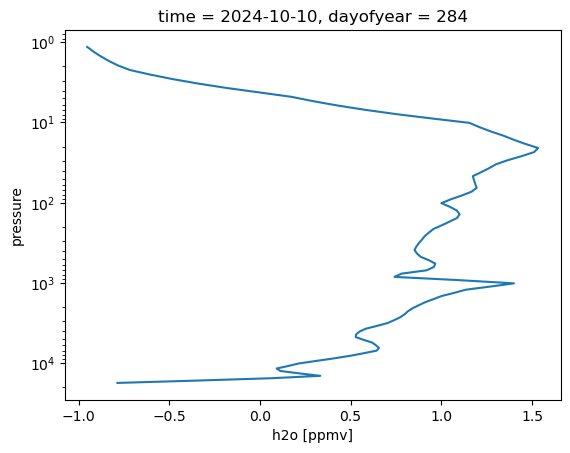

In [27]:
ds_mls_interp['h2o'].sel(time = sel_time).plot(y = 'pressure', yincrease = False)
plt.yscale('log')

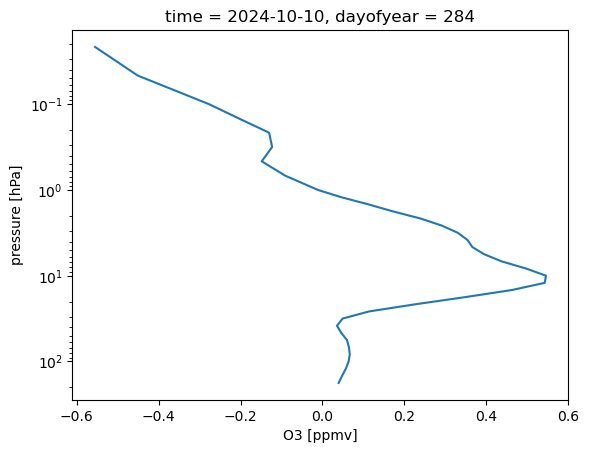

In [22]:
ds_mls['O3'].sel(time = sel_time).plot(y = 'pressure', yincrease = False)
plt.yscale('log')

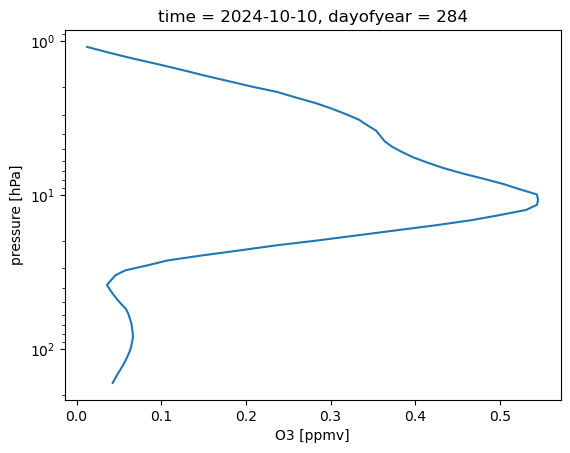

In [21]:
ds_mls_interp['O3'].sel(time = sel_time).plot(y = 'pressure', yincrease = False)
plt.yscale('log')

(100000, 1)

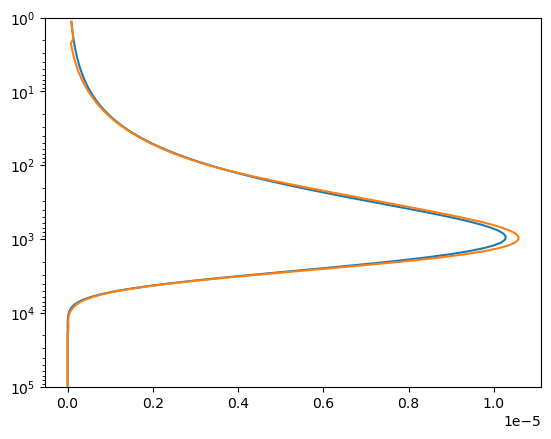

In [86]:
plt.plot(atmosphere['O3'].squeeze(), atmosphere['plev'])
plt.plot(diff_o3.squeeze(), atmosphere['plev'])
plt.yscale('log')
plt.ylim(100000,1)

(100000, 1)

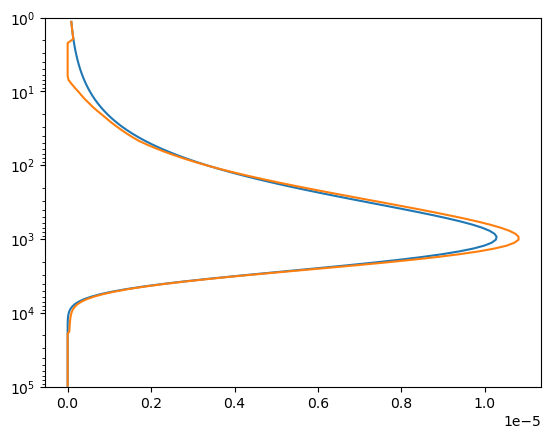

In [28]:
plt.plot(atmosphere['O3'].squeeze(), atmosphere['plev'])
plt.plot(diff_o3.squeeze(), atmosphere['plev'])
plt.yscale('log')
plt.ylim(100000,1)

(-1e-06, 2e-06)

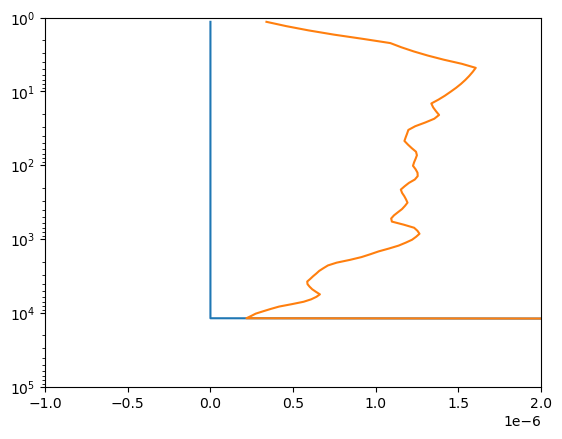

In [87]:
plt.plot(atmosphere['H2O'].squeeze(), atmosphere['plev'])
plt.plot(diff_wv.squeeze(), atmosphere['plev'])
plt.yscale('log')
plt.ylim(100000,1)
#lt.xscale('log')
plt.xlim(-1e-6,2e-6)

(-1e-06, 2e-06)

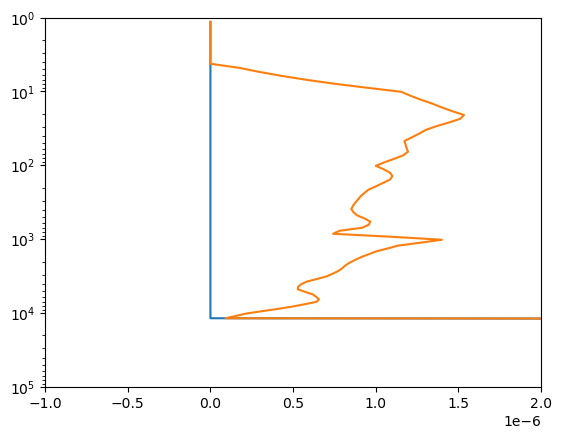

In [29]:
plt.plot(atmosphere['H2O'].squeeze(), atmosphere['plev'])
plt.plot(diff_wv.squeeze(), atmosphere['plev'])
plt.yscale('log')
plt.ylim(100000,1)
#lt.xscale('log')
plt.xlim(-1e-6,2e-6)

In [49]:
atmosphere2['H2O'].shape

(1, 127)

In [45]:
atmosphere2 = atmosphere.copy()
atmosphere2['H2O'][0,:] = diff_wv
atmosphere2['O3'][0,:] = diff_o3

In [50]:
ds_hr_wo, ds_fluxes_wo = rad_cal(atmosphere)
ds_hr_w, ds_fluxes_w = rad_cal(atmosphere2)


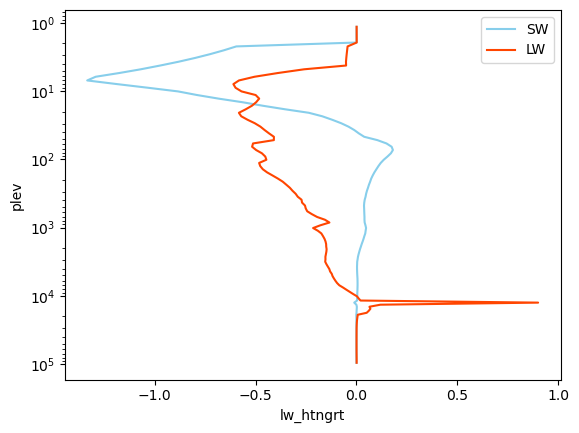

In [51]:
diff = ds_hr_w-ds_hr_wo
diff['sw_htngrt'].plot(yincrease = False, y = 'plev', color = 'skyblue', label  = 'SW')
diff['lw_htngrt'].plot(yincrease = False, y = 'plev', color='orangered', label = 'LW')
plt.legend()

plt.yscale('log')

In [77]:
np.arange(60,94,4)

array([60, 64, 68, 72, 76, 80, 84, 88, 92])

In [5]:
s_year = 2024
e_year = 2025
s_month = 9
e_month = 3
time_start = f"{s_year}-{s_month:02d}"
time_end = f"{e_year}-{e_month:02d}"
ds_mls_sel = ds_mls.sel(time = slice(time_start, time_end),)
ds_mls_sel

<xarray.Dataset> Size: 6kB
Dimensions:      (time: 7, pressure: 37)
Coordinates:
  * time         (time) datetime64[ns] 56B 2024-09-30 2024-10-31 ... 2025-03-31
  * pressure     (pressure) float32 148B 1.778e+04 1.468e+04 ... 2.154 1.0
Data variables:
    temperature  (time, pressure) float64 2kB ...
    O3           (time, pressure) float64 2kB ...
    h2o          (time, pressure) float64 2kB ...
Attributes:
    title:    Aura MLS v6.01 Level-2 data product
    history:  Postprocessed by WEGC; screened using MLS precision estimates a...

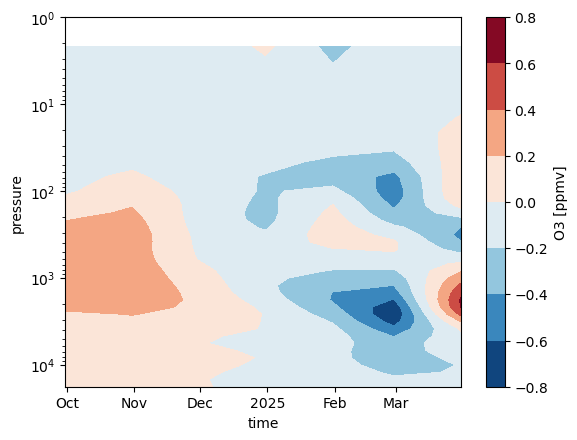

In [15]:
ds_mls_sel['O3'].plot.contourf(x = 'time', yincrease = False)
plt.yscale('log')

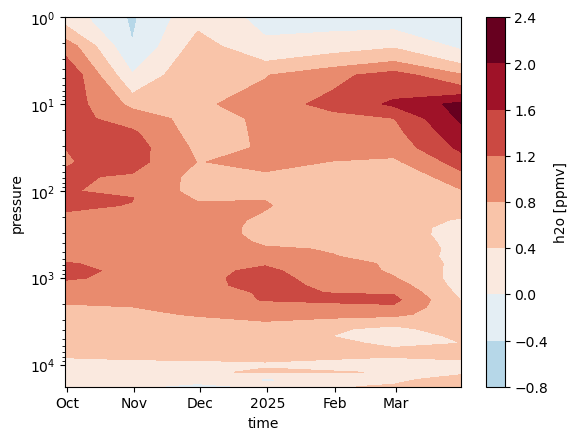

In [16]:
ds_mls_sel['h2o'].plot.contourf(x = 'time', yincrease = False)
plt.yscale('log')

In [12]:
ds_mls_sel[['O3','h2o']].to_netcdf(f'O3+WV_{s_year}{s_month:02d}-{e_year}{e_month:02d}.nc')

In [8]:
switch_ls = ['both','H2O','O3']
temp_ls = []
for switch in switch_ls:
    diff_time_ls = perturb(ds_mls_sel, atmosphere, perturb_switch=switch)    
    temp = process_diff(diff_time_ls, switch)
    temp_ls.append(temp)

KeyboardInterrupt: 

In [231]:
diff_all_all = xr.concat(temp_ls, dim = 'perturb')
diff_all_all['SUM'] = diff_all_all['lw_htngrt']+diff_all_all['sw_htngrt']
diff_all_all = diff_all_all.rename({'lw_htngrt': 'LW', 'sw_htngrt': 'SW'})
diff_all_all.to_netcdf(f'MLS_RRTMG_{time_start}-{time_end}.nc')

MLS_RRTMG_2024-09--2025-03.pdf


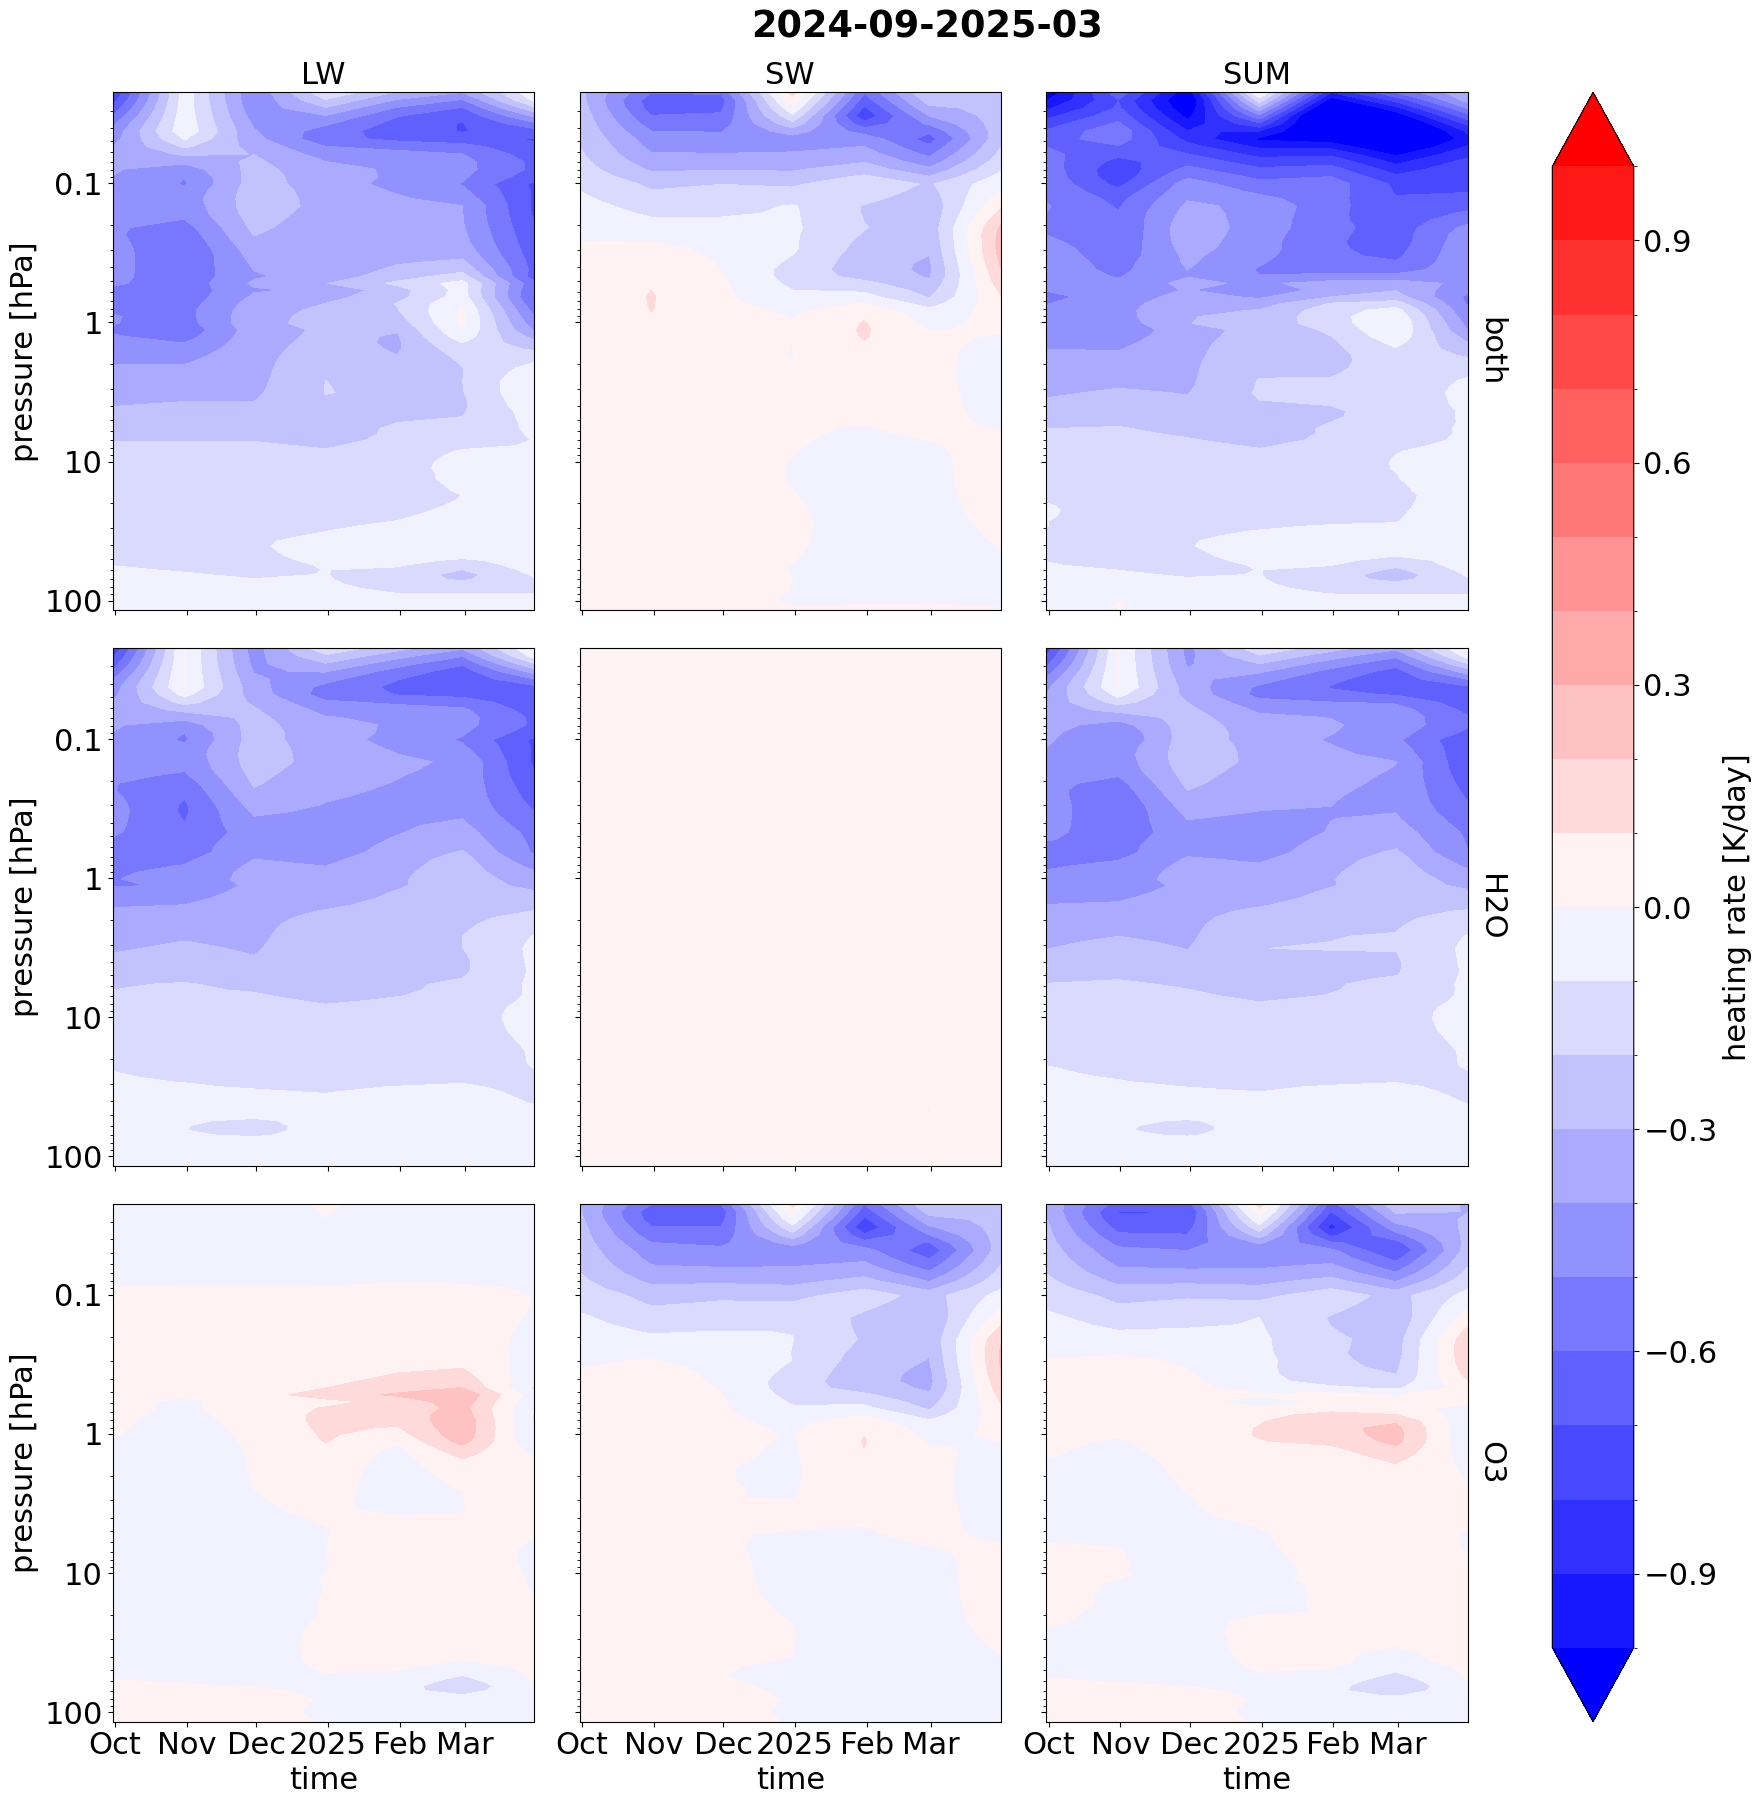

In [232]:
plt.rcParams.update({"font.size": 22})
temp_plot = diff_all_all.sel(
    plev = slice(120,0.02)
).to_array().mean('zenith')
temp_plot.name = 'hr'
temp_plot.attrs['units'] = 'K/day'
temp_plot.attrs['long_name'] = 'heating rate'

p = temp_plot.plot.contourf(
    x = 'time', y = 'plev', yincrease = False, 
    robust = True, levels = np.linspace(-1,1,21), 
    col = 'variable', row = 'perturb',
    extend = 'both', cmap = 'bwr',
    size = 6
)
p.set_titles(template = '{value}')
p.fig.suptitle(f'{time_start}-{time_end}', y = 1.01, fontweight = 'bold')

for ax in p.axes.flat:
    ax.set_yscale('log')
    ax.set_yticks([100,10,1,0.1])
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)


outfile = f'MLS_RRTMG_{time_start}--{time_end}.pdf'
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

## SOCOL

In [6]:
infile_path = Path("/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/")
what = "chem_mm_zon"
infiles_w = list(infile_path.glob(f"socol4_htt1?_{what}*"))
infiles_wo = list(infile_path.glob(f"socol4_htt2?_{what}*"))

In [140]:
ds_w_chem = (
    xr.open_mfdataset(
        infiles_w,
        parallel=True,  #  will be performed in parallel using dask.delayed
        combine="nested",
        concat_dim=["ens"],
    )
    .pipe(process_chem, deseasonalize=False, upper_limit=None, lower_limit = None).sortby('plev', ascending=False)
    .load()
)
ds_w_chem

<xarray.Dataset> Size: 43MB
Dimensions:  (ens: 10, time: 60, plev: 47, lat: 96, lon: 1)
Coordinates:
  * time     (time) datetime64[ns] 480B 2021-01-31 2021-02-28 ... 2025-12-31
  * plev     (plev) float64 376B 1.009e+03 995.4 971.4 ... 0.04281 0.009946
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 8B 0.0
Dimensions without coordinates: ens
Data variables:
    te_m     (ens, time, plev, lat, lon) float32 11MB 244.6 246.3 ... 181.9
    u_m      (ens, time, plev, lat, lon) float32 11MB -2.329 -2.021 ... -1.813
    O3_m     (ens, time, plev, lat, lon) float32 11MB 3.621e-08 ... 4.087e-08
    H2O_m    (ens, time, plev, lat, lon) float32 11MB 0.0004767 ... 4.499e-06
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Tue Mar 12 10:25:13 2024: cdo cat ss4.nc /scratch/snx3000/a...
    frequency:    mon
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [141]:
ds_wo_chem = (
    xr.open_mfdataset(
        infiles_wo,
        parallel=True,  #  will be performed in parallel using dask.delayed
        combine="nested",
        concat_dim=["ens"],
    )
    .pipe(process_chem, deseasonalize=False, upper_limit=None, lower_limit = None).sortby('plev', ascending=False)
    .load()
)
ds_wo_chem

<xarray.Dataset> Size: 43MB
Dimensions:  (ens: 10, time: 60, plev: 47, lat: 96, lon: 1)
Coordinates:
  * time     (time) datetime64[ns] 480B 2021-01-31 2021-02-28 ... 2025-12-31
  * plev     (plev) float64 376B 1.009e+03 995.4 971.4 ... 0.04281 0.009946
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 8B 0.0
Dimensions without coordinates: ens
Data variables:
    te_m     (ens, time, plev, lat, lon) float32 11MB nan nan ... 180.9 180.4
    u_m      (ens, time, plev, lat, lon) float32 11MB nan nan ... 2.075 2.074
    O3_m     (ens, time, plev, lat, lon) float32 11MB nan nan ... 4.212e-08
    H2O_m    (ens, time, plev, lat, lon) float32 11MB nan nan ... 4.493e-06
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Thu Feb 29 16:07:22 2024: cdo cat ss4.nc /scratch/snx3000/a...
    frequency:    mon
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [157]:
pcap_w = polar_sel(ds_w_chem)#[['O3_m','te_m','H2O_m']].sel(time = '2024-02', lat = slice(None,60))
pcap_wo = polar_sel(ds_wo_chem)
diff_pcap = pcap_w-pcap_wo

(100000, 1)

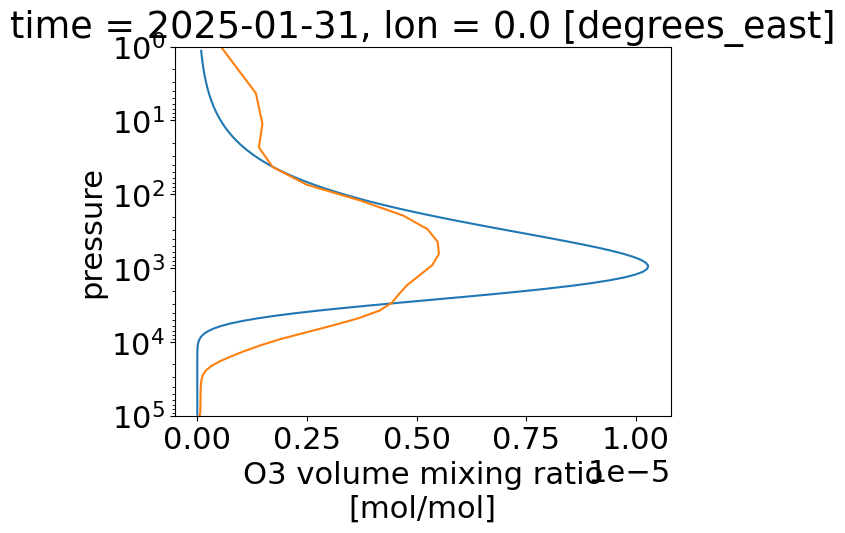

In [176]:
plt.plot(atmosphere['O3'].squeeze(), atmosphere['plev'])
pcap_w['O3'].sel(time = '2025-01').squeeze().plot(y = 'pressure', yincrease = False)
plt.yscale('log')
plt.ylim(100000,1)

(100000, 1)

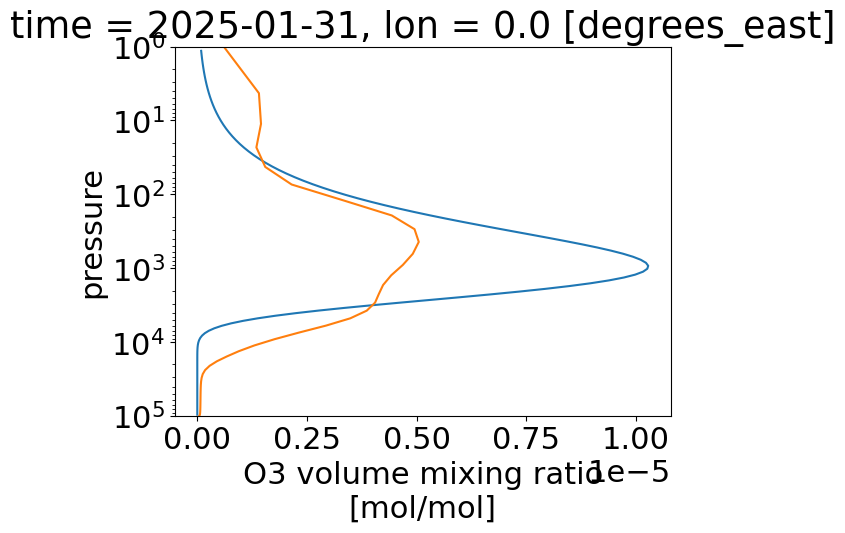

In [177]:
plt.plot(atmosphere['O3'].squeeze(), atmosphere['plev'])
pcap_wo['O3'].sel(time = '2025-01').squeeze().plot(y = 'pressure', yincrease = False)
plt.yscale('log')
plt.ylim(100000,1)

(100000, 1)

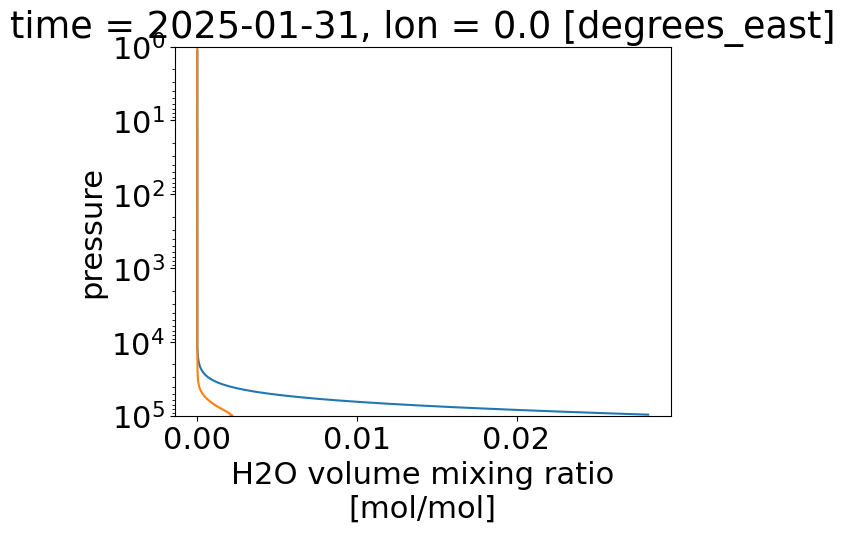

In [168]:
plt.plot(atmosphere['H2O'].squeeze(), atmosphere['plev'])
pcap_w['h2o'].sel(time = '2025-01').squeeze().plot(y = 'pressure', yincrease = False)
plt.yscale('log')
plt.ylim(100000,1)

In [202]:
s_year = 2023
e_year = 2024
s_month = 9
e_month = 3
time_start = f"{s_year}-{s_month:02d}"
time_end = f"{e_year}-{e_month:02d}"
diff_pcap_sel = diff_pcap.sel(time = slice(time_start, time_end),pressure = slice(12000,.1))
diff_pcap_sel

<xarray.Dataset> Size: 4kB
Dimensions:   (time: 7, pressure: 22)
Coordinates:
  * time      (time) datetime64[ns] 56B 2023-09-30 2023-10-31 ... 2024-03-31
  * pressure  (pressure) float64 176B 1.107e+04 9.102e+03 ... 4.281 0.9946
    lon       float64 8B 0.0
Data variables:
    O3        (time, pressure) float64 1kB -5.955e-09 -3.191e-08 ... -3.048e-09
    te_m      (time, pressure) float64 1kB -0.2102 -0.2579 ... 0.5046 1.03
    h2o       (time, pressure) float64 1kB 3.173e-09 2.898e-08 ... -4.258e-08
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    frequency:    mon
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

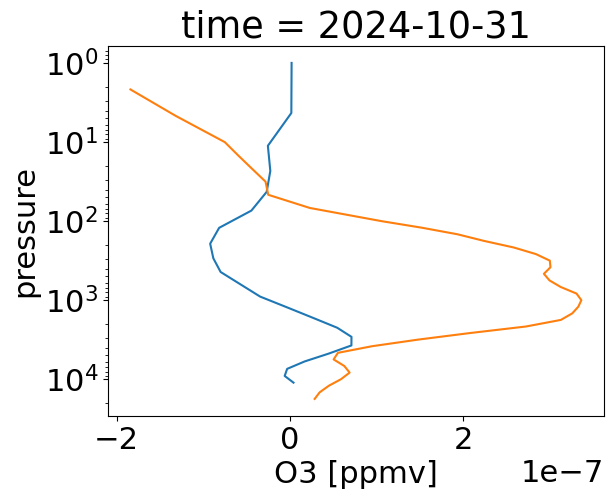

In [203]:
diff_pcap_sel['O3'].sel(time = '2023-10').plot(y = 'pressure', yincrease= False)
(ds_mls_sel['O3'].sel(time = '2024-10')/1e6).plot(y = 'pressure', yincrease= False)
plt.yscale('log')

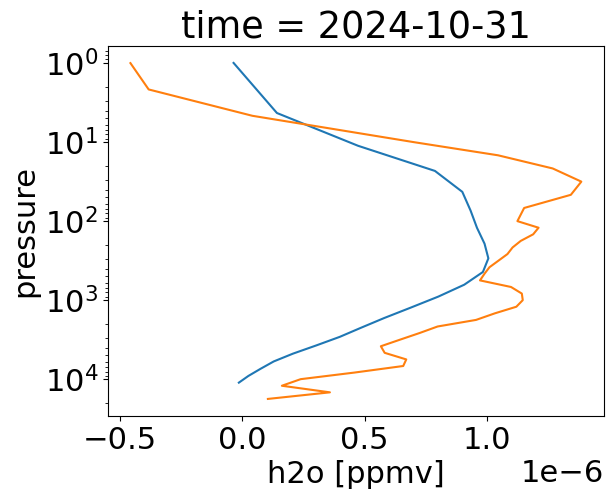

In [204]:
diff_pcap_sel['h2o'].sel(time = '2023-10').plot(y = 'pressure', yincrease= False)
(ds_mls_sel['h2o'].sel(time = '2024-10')/1e6).plot(y = 'pressure', yincrease= False)
plt.yscale('log')

In [216]:
s_year = 2024
e_year = 2025
s_month = 9
e_month = 3
time_start = f"{s_year}-{s_month:02d}"
time_end = f"{e_year}-{e_month:02d}"
diff_pcap_sel = diff_pcap.sel(time = slice(time_start, time_end),pressure = slice(12000,.1))
diff_pcap_sel

<xarray.Dataset> Size: 4kB
Dimensions:   (time: 7, pressure: 22)
Coordinates:
  * time      (time) datetime64[ns] 56B 2024-09-30 2024-10-31 ... 2025-03-31
  * pressure  (pressure) float64 176B 1.107e+04 9.102e+03 ... 4.281 0.9946
    lon       float64 8B 0.0
Data variables:
    O3        (time, pressure) float64 1kB -1.276e-08 -1.585e-08 ... 8.598e-10
    te_m      (time, pressure) float64 1kB -0.4214 -0.3373 ... 2.444 1.78
    h2o       (time, pressure) float64 1kB 7.3e-08 8.25e-08 ... -9.29e-08
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    frequency:    mon
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [217]:
switch_ls = ['both','H2O','O3']
temp_ls = []
for switch in switch_ls:
    diff_time_ls = perturb(diff_pcap_sel[['h2o','O3']]*1e6, atmosphere, perturb_switch=switch)    
    temp = process_diff(diff_time_ls, switch)
    temp_ls.append(temp)

In [218]:
diff_all_all = xr.concat(temp_ls, dim = 'perturb')
diff_all_all['SUM'] = diff_all_all['lw_htngrt']+diff_all_all['sw_htngrt']
diff_all_all = diff_all_all.rename({'lw_htngrt': 'LW', 'sw_htngrt': 'SW'})
diff_all_all.to_netcdf(f'SOCOL_RRTMG_{time_start}-{time_end}.nc')

SOCOL_RRTMG_2024-09--2025-03.pdf


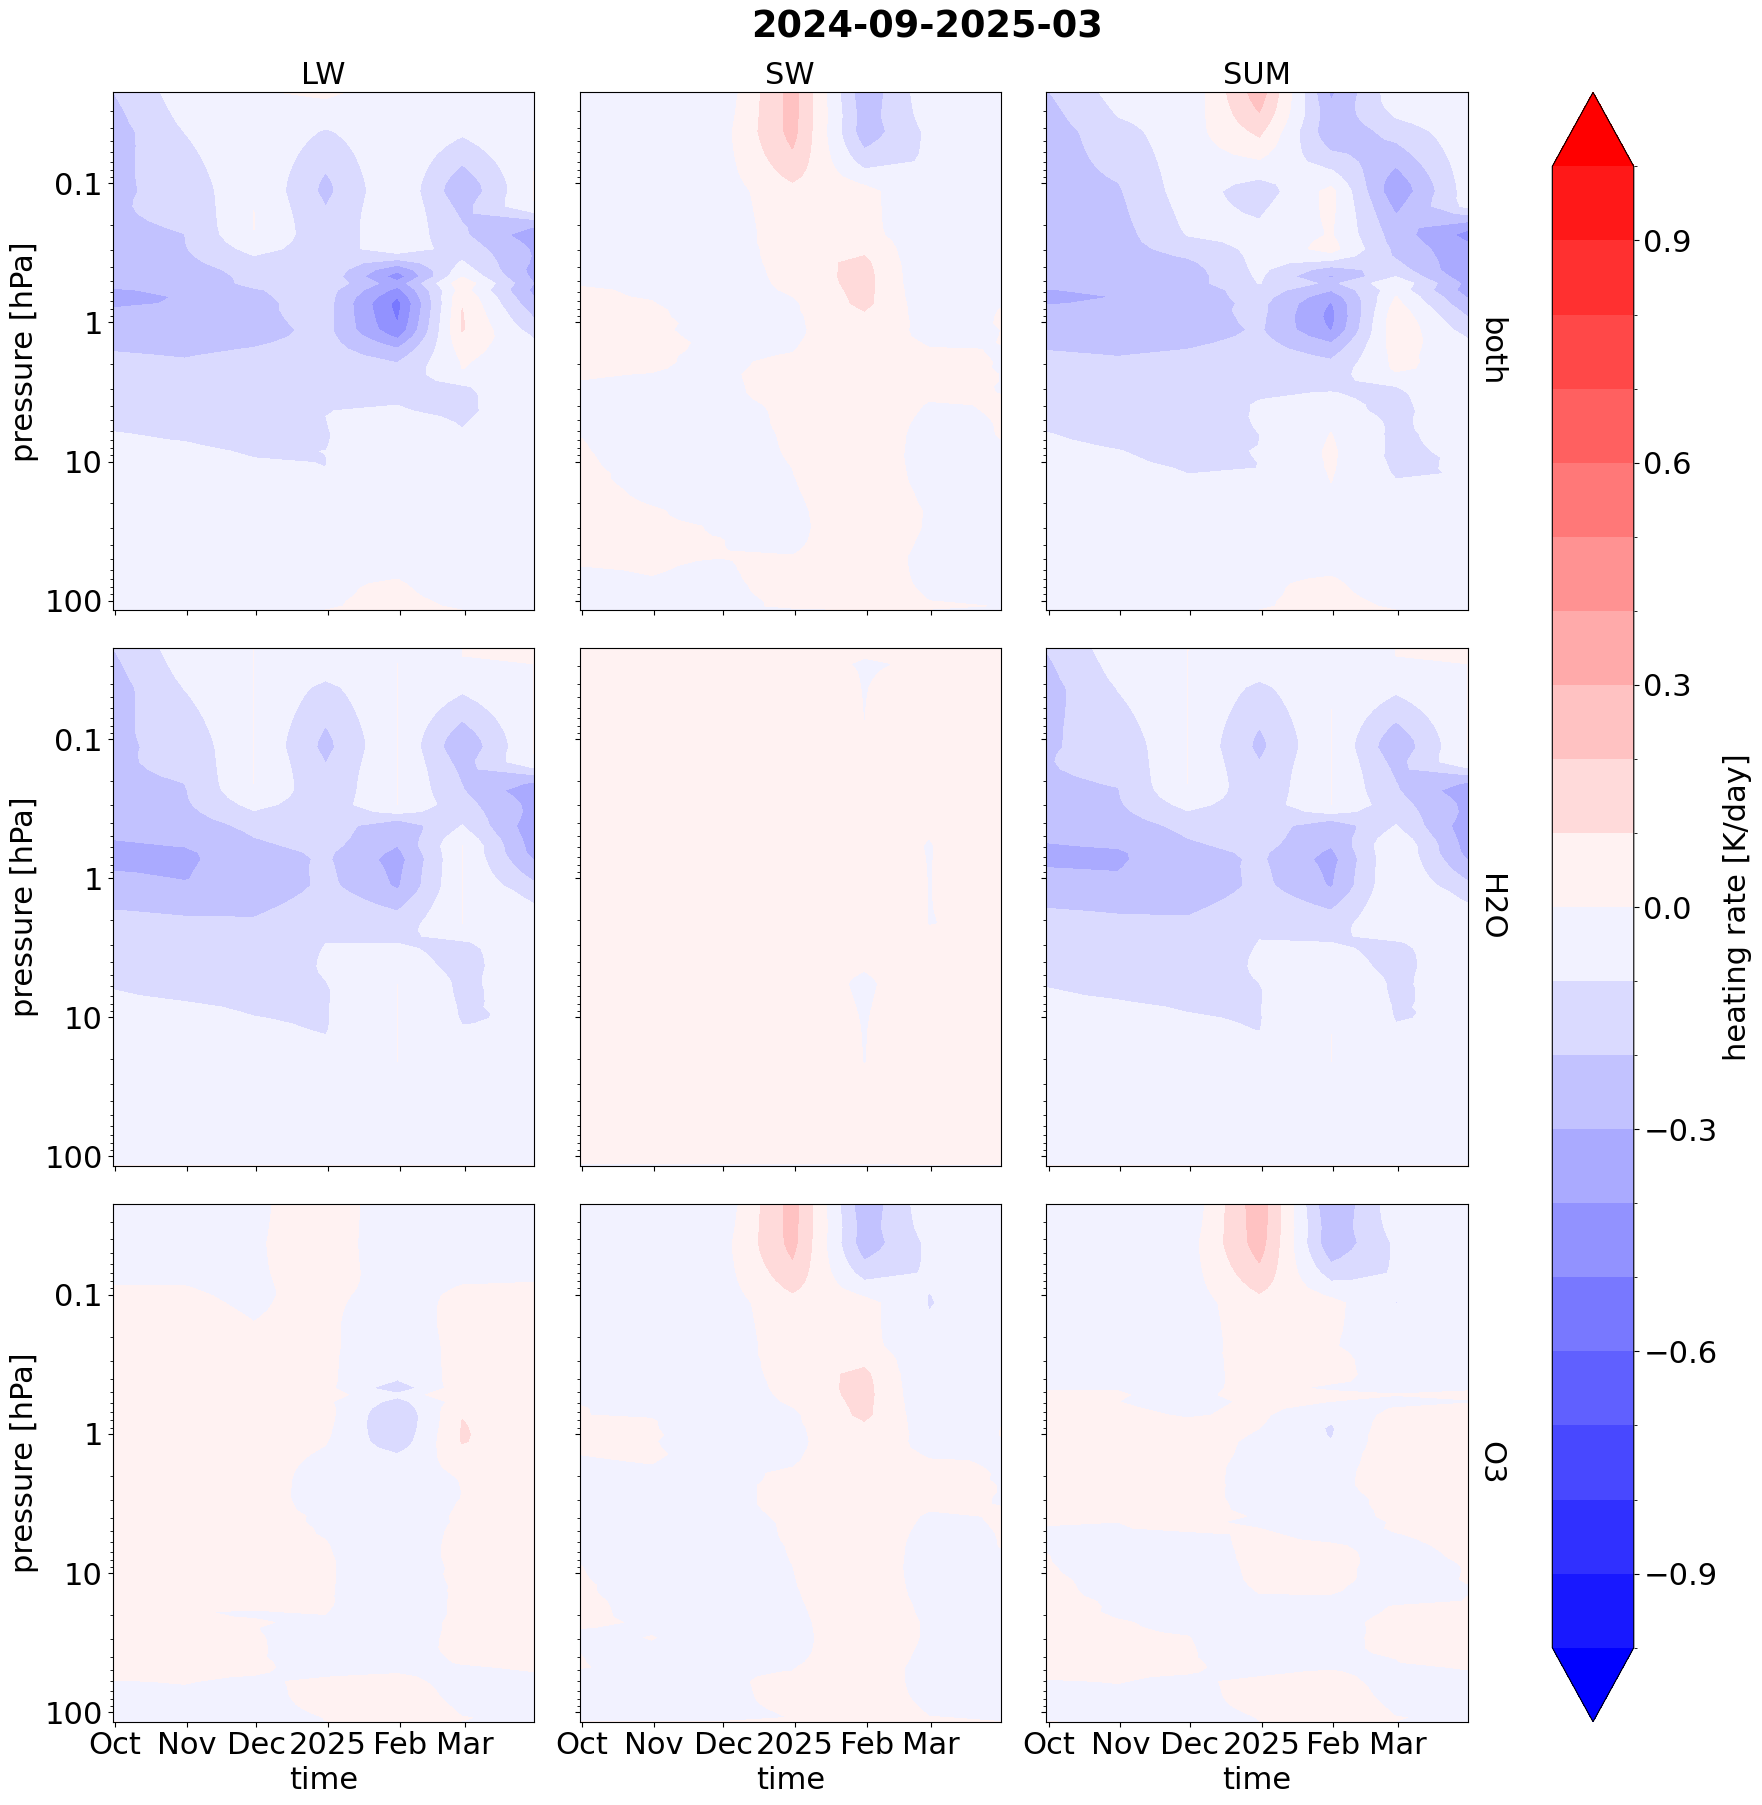

In [219]:
plt.rcParams.update({"font.size": 22})
temp_plot = diff_all_all.sel(
    plev = slice(120,0.02)
).to_array().mean('zenith')
temp_plot.name = 'hr'
temp_plot.attrs['units'] = 'K/day'
temp_plot.attrs['long_name'] = 'heating rate'

p = temp_plot.plot.contourf(
    x = 'time', y = 'plev', yincrease = False, 
    robust = True, levels = np.linspace(-1,1,21), 
    col = 'variable', row = 'perturb',
    extend = 'both', cmap = 'bwr',
    size = 6
)
p.set_titles(template = '{value}')
p.fig.suptitle(f'{time_start}-{time_end}', y = 1.01, fontweight = 'bold')

for ax in p.axes.flat:
    ax.set_yscale('log')
    ax.set_yticks([100,10,1,0.1])
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)


outfile = f'SOCOL_RRTMG_{time_start}--{time_end}.pdf'
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

### Daily

In [4]:
infile_path = Path("/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/")

what = "H2O_m"
infiles_w = list(infile_path.glob(f"socol4_htt1*{what}*daily.nc"))
infiles_wo = list(infile_path.glob(f"socol4_htt2*{what}*daily.nc"))
infiles_w

[PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt10_H2O_m_2021-2025_daily.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt11_H2O_m_2021-2025_daily.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt13_H2O_m_2021-2025_daily.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt12_H2O_m_2021-2025_daily.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt17_H2O_m_2021-2025_daily.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt16_H2O_m_2021-2025_daily.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt14_H2O_m_2021-2025_daily.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt15_H2O_m_2021-2025_daily.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt18_H2O_m_2021-2025_daily.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt19_H2O_m_2021-2025_daily.nc')]

In [5]:
ds_w_wv = xr.open_mfdataset(
    infiles_w,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(
    process_daily, deseasonalize=False
)  # .chunk(plev = 1, time = 365)
# ds_w_wv["ens"] = ens_name_ls
ds_w_wv

<xarray.Dataset> Size: 66GB
Dimensions:  (ens: 10, time: 1826, plev: 49, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * plev     (plev) float64 392B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Dimensions without coordinates: ens
Data variables:
    H2O_m    (ens, time, plev, lat, lon) float32 66GB dask.array<chunksize=(1, 1826, 49, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Mon Feb 26 14:43:50 2024: cdo cat rr3.nc /scratch/snx3000/a...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [6]:
ds_wo_wv = xr.open_mfdataset(
    infiles_wo,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(process_daily, deseasonalize=False)
ds_wo_wv

/tmp/ipykernel_569229/2679231195.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds_wo_wv = xr.open_mfdataset(


<xarray.Dataset> Size: 66GB
Dimensions:  (ens: 10, time: 1826, plev: 49, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * plev     (plev) float64 392B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Dimensions without coordinates: ens
Data variables:
    H2O_m    (ens, time, plev, lat, lon) float32 66GB dask.array<chunksize=(1, 1461, 49, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Mon Feb 26 16:11:55 2024: cdo cat rr3.nc /scratch/snx3000/a...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [7]:
what = "ozone"
infiles_w = list(infile_path.glob(f"socol4_htt1*{what}*daily.nc"))
infiles_wo = list(infile_path.glob(f"socol4_htt2*{what}*daily.nc"))

In [8]:
ds_w_o3 = xr.open_mfdataset(
    infiles_w,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(
    process_daily, deseasonalize=False
)  # .chunk(plev = 1, time = 365)
# ds_w_wv["ens"] = ens_name_ls
ds_w_o3

<xarray.Dataset> Size: 836MB
Dimensions:  (ens: 10, time: 1461, lat: 96, lon: 1, plev: 49)
Coordinates:
  * time     (time) datetime64[ns] 12kB 2022-01-01 2022-01-02 ... 2025-12-31
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 8B 0.0
  * plev     (plev) float64 392B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
Dimensions without coordinates: ens
Data variables:
    aps      (ens, time, lat, lon) float32 6MB dask.array<chunksize=(1, 1461, 96, 1), meta=np.ndarray>
    geosp    (ens, time, lat, lon) float32 6MB dask.array<chunksize=(1, 1461, 96, 1), meta=np.ndarray>
    O3_m     (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
    HO2_m    (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
    OH_m     (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.1.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  Max-Planck-Institute for Meteorology
    history:      Fri May 16 12:10:28 2025: cdo ml2pl,0.9946,4.2806,11.1230,2...
    CDO:          Climate Data Operators version 2.1.1 (https://mpimet.mpg.de...

In [9]:
ds_wo_o3 = xr.open_mfdataset(
    infiles_wo,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(process_daily, deseasonalize=False)
ds_wo_o3

<xarray.Dataset> Size: 836MB
Dimensions:  (ens: 10, time: 1461, lat: 96, lon: 1, plev: 49)
Coordinates:
  * time     (time) datetime64[ns] 12kB 2022-01-01 2022-01-02 ... 2025-12-31
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 8B 0.0
  * plev     (plev) float64 392B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
Dimensions without coordinates: ens
Data variables:
    aps      (ens, time, lat, lon) float32 6MB dask.array<chunksize=(1, 1461, 96, 1), meta=np.ndarray>
    geosp    (ens, time, lat, lon) float32 6MB dask.array<chunksize=(1, 1461, 96, 1), meta=np.ndarray>
    O3_m     (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
    HO2_m    (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
    OH_m     (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.1.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  Max-Planck-Institute for Meteorology
    history:      Fri May 16 12:10:49 2025: cdo ml2pl,0.9946,4.2806,11.1230,2...
    CDO:          Climate Data Operators version 2.1.1 (https://mpimet.mpg.de...

In [10]:
ds_w_chem = xr.merge([ds_w_wv['H2O_m'], ds_w_o3['O3_m']]).mean('lon')
ds_wo_chem = xr.merge([ds_wo_wv['H2O_m'], ds_wo_o3['O3_m']]).mean('lon')
ds_w_chem

/tmp/ipykernel_569229/3187939764.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds_w_chem = xr.merge([ds_w_wv['H2O_m'], ds_w_o3['O3_m']]).mean('lon')
/tmp/ipykernel_569229/3187939764.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lon' ('lon',) The recommendation is to set join explicitly for this case.
  ds_w_chem = xr.merge([ds_w_wv['H2O_m'], ds_w_o3['O3_m']]).mean('lon')
/tmp/ipykernel_569229/3187939764.py:1: FutureWarning

<xarray.Dataset> Size: 873MB
Dimensions:  (time: 1826, lat: 122, plev: 49, ens: 10)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * lat      (lat) float64 976B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
  * plev     (plev) float64 392B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
Dimensions without coordinates: ens
Data variables:
    H2O_m    (ens, time, plev, lat) float32 437MB dask.array<chunksize=(1, 1826, 49, 96), meta=np.ndarray>
    O3_m     (ens, time, plev, lat) float32 437MB dask.array<chunksize=(1, 1461, 49, 96), meta=np.ndarray>
Attributes:
    long_name:         H2O volume mixing ratio
    units:             mol/mol
    code:              35
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48
    institution:       MPIMET

In [11]:
pcap_w = polar_sel(ds_w_chem)#[['O3_m','te_m','H2O_m']].sel(time = '2024-02', lat = slice(None,60))
pcap_wo = polar_sel(ds_wo_chem)
diff_pcap = pcap_w-pcap_wo
diff_pcap

<xarray.Dataset> Size: 1MB
Dimensions:   (time: 1826, pressure: 49)
Coordinates:
  * time      (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * pressure  (pressure) float64 392B 0.9946 4.281 11.12 ... 9.954e+04 1.009e+05
Data variables:
    O3        (time, pressure) float64 716kB dask.array<chunksize=(1461, 49), meta=np.ndarray>
    h2o       (time, pressure) float64 716kB dask.array<chunksize=(1461, 49), meta=np.ndarray>
Attributes:
    long_name:         H2O volume mixing ratio
    units:             mol/mol
    code:              35
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48
    institution:       MPIMET

In [23]:
s_year = 2023
e_year = 2024
s_month = 9
e_month = 3
time_start = f"{s_year}-{s_month:02d}"
time_end = f"{e_year}-{e_month:02d}"
diff_pcap_sel = diff_pcap.sel(time = slice(time_start, time_end),pressure = slice(.1,12000)).load()
diff_pcap_sel

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 10.51 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.Dataset> Size: 84kB
Dimensions:   (time: 213, pressure: 24)
Coordinates:
  * time      (time) datetime64[ns] 2kB 2023-09-01 2023-09-02 ... 2024-03-31
  * pressure  (pressure) float64 192B 0.9946 4.281 11.12 ... 1e+04 1.107e+04
Data variables:
    O3        (time, pressure) float64 41kB -9.211e-09 -3.059e-08 ... -1.601e-08
    h2o       (time, pressure) float64 41kB 2.746e-07 5.511e-07 ... 2.892e-08
Attributes:
    long_name:         H2O volume mixing ratio
    units:             mol/mol
    code:              35
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48
    institution:       MPIMET

In [24]:
switch_ls = ['both','H2O','O3']
temp_ls = []
for switch in switch_ls:
    print(switch)
    diff_time_ls = perturb(diff_pcap_sel[['h2o','O3']]*1e6, atmosphere, perturb_switch=switch)    
    temp = process_diff(diff_time_ls, switch)
    temp_ls.append(temp)

both


/tmp/ipykernel_569229/1803222598.py:80: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  diff_time_ls.append(xr.concat(diff_ls, dim = 'zenith'))
/tmp/ipykernel_569229/1803222598.py:80: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  diff_time_ls.append(xr.concat(diff_ls, dim = 'zenith'))
/tmp/ipykernel_569229/180322

H2O


/tmp/ipykernel_569229/1803222598.py:80: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  diff_time_ls.append(xr.concat(diff_ls, dim = 'zenith'))
/tmp/ipykernel_569229/1803222598.py:80: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  diff_time_ls.append(xr.concat(diff_ls, dim = 'zenith'))
/tmp/ipykernel_569229/180322

O3


/tmp/ipykernel_569229/1803222598.py:80: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  diff_time_ls.append(xr.concat(diff_ls, dim = 'zenith'))
/tmp/ipykernel_569229/1803222598.py:80: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  diff_time_ls.append(xr.concat(diff_ls, dim = 'zenith'))
/tmp/ipykernel_569229/180322

In [25]:
diff_all_all = xr.concat(temp_ls, dim = 'perturb')
diff_all_all['SUM'] = diff_all_all['lw_htngrt']+diff_all_all['sw_htngrt']
diff_all_all = diff_all_all.rename({'lw_htngrt': 'LW', 'sw_htngrt': 'SW'})
diff_all_all.to_netcdf(f'SOCOL_RRTMG_{time_start}-{time_end}_daily.nc')

/tmp/ipykernel_569229/3662356272.py:19: FutureWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in p.axes.flat:


SOCOL_RRTMG_2023-09--2024-03_daily.pdf


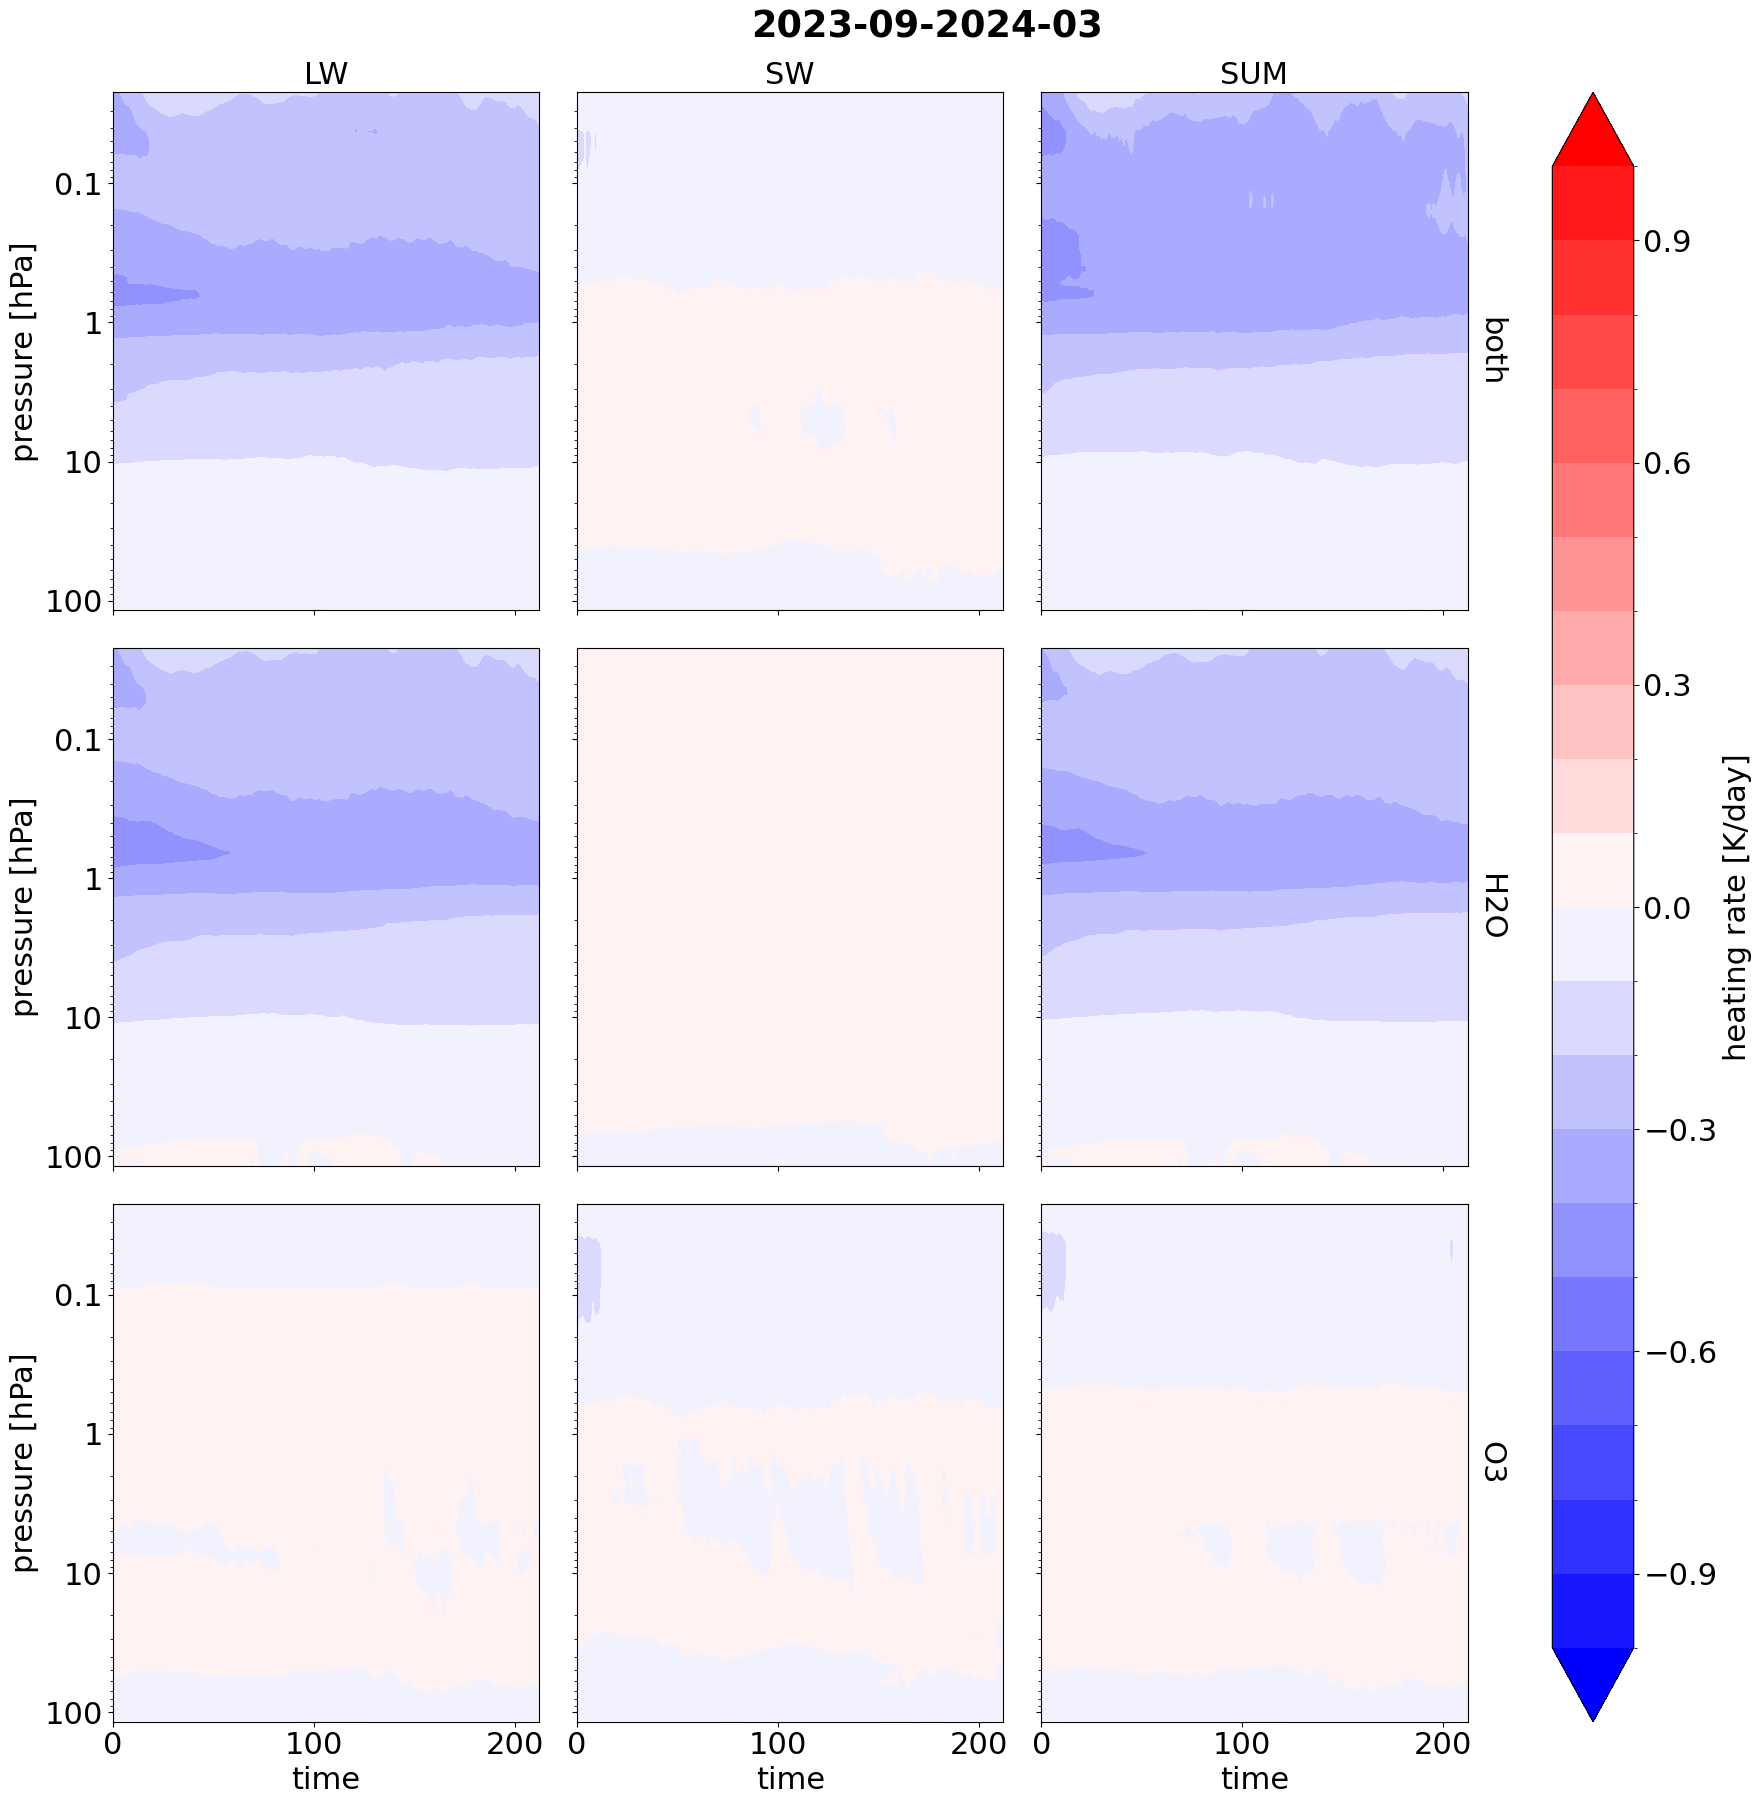

In [26]:
plt.rcParams.update({"font.size": 22})
temp_plot = diff_all_all.sel(
    plev = slice(120,0.02)
).to_array().mean('zenith')
temp_plot.name = 'hr'
temp_plot.attrs['units'] = 'K/day'
temp_plot.attrs['long_name'] = 'heating rate'

p = temp_plot.plot.contourf(
    x = 'time', y = 'plev', yincrease = False, 
    robust = True, levels = np.linspace(-1,1,21), 
    col = 'variable', row = 'perturb',
    extend = 'both', cmap = 'bwr',
    size = 6
)
p.set_titles(template = '{value}')
p.fig.suptitle(f'{time_start}-{time_end}', y = 1.01, fontweight = 'bold')

for ax in p.axes.flat:
    ax.set_yscale('log')
    ax.set_yticks([100,10,1,0.1])
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)


outfile = f'SOCOL_RRTMG_{time_start}--{time_end}_daily.pdf'
print(outfile)
plt.savefig(outfile, bbox_inches="tight")